<a href="https://colab.research.google.com/github/harishmk31/24ADI003_24BAD031/blob/main/Experiment-05/scenario2_exp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Best Depth: 1
Accuracy: 0.7886178861788617
Precision: 0.7596153846153846
Recall: 0.9875
F1 Score: 0.8586956521739131
Training Accuracy: 0.814663951120163
Testing Accuracy: 0.7886178861788617
ApplicantIncome : 0.0
LoanAmount : 0.0
Credit_History : 1.0
Education : 0.0
Property_Area : 0.0


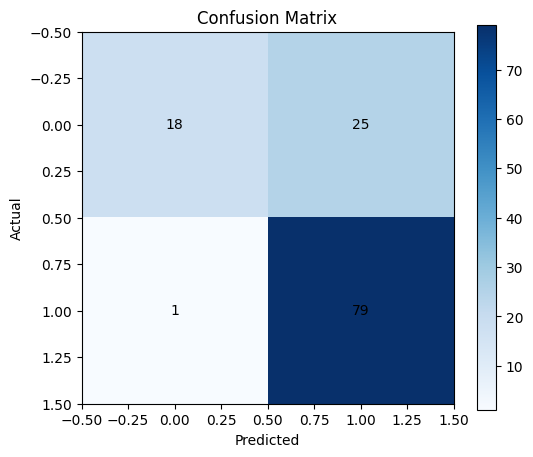

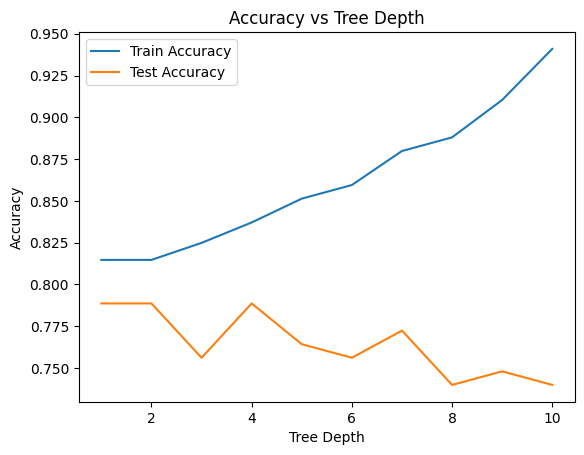

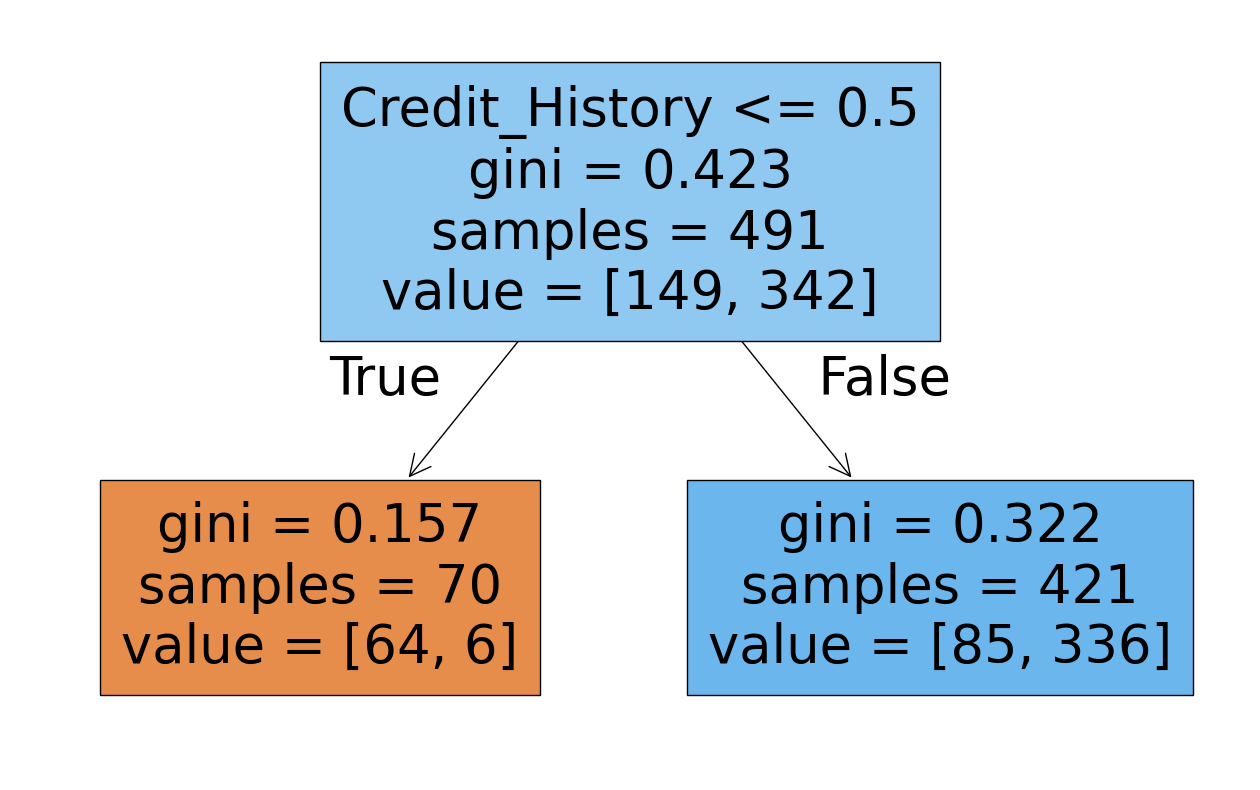

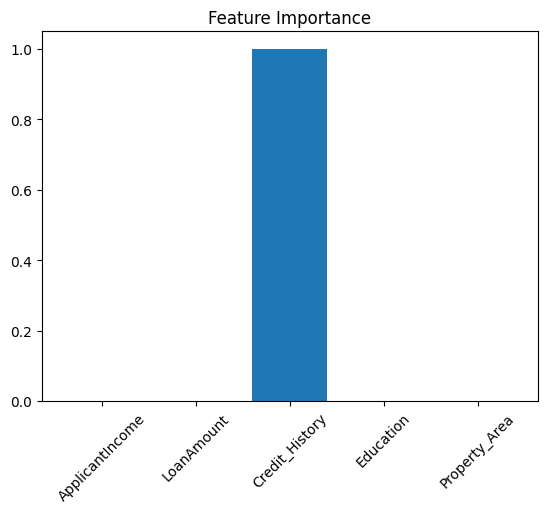

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv("loan_prediction.csv")

df = df[['ApplicantIncome','LoanAmount','Credit_History','Education','Property_Area','Loan_Status']]

df.fillna(df.mode().iloc[0], inplace=True)

le = LabelEncoder()
df['Education'] = le.fit_transform(df['Education'])
df['Property_Area'] = le.fit_transform(df['Property_Area'])
df['Loan_Status'] = le.fit_transform(df['Loan_Status'])

X = df[['ApplicantIncome','LoanAmount','Credit_History','Education','Property_Area']]
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

depths = range(1,11)
train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

best_depth = depths[np.argmax(test_acc)]
print("Best Depth:", best_depth)

dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("Training Accuracy:", accuracy_score(y_train, dt.predict(X_train)))
print("Testing Accuracy:", accuracy_score(y_test, y_pred))

importance = dt.feature_importances_
for i,v in enumerate(importance):
    print(X.columns[i],":",v)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j,i,cm[i,j],ha='center',va='center',color='black')

plt.colorbar()
plt.show()

plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy vs Tree Depth")
plt.show()

plt.figure(figsize=(16,10))
plot_tree(dt, feature_names=X.columns, filled=True)
plt.show()

plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()